# System Setup

## Imports and Installs

### Installs

In [78]:
!pip install geopandas
!pip install geojson
!pip install overpass
!pip install alphashape

### Imports

In [79]:
import pandas as pd
import json
import geojson
#https://github.com/mvexel/overpass-api-python-wrapper/blob/main/README.md
import overpass
#https://pypi.org/project/osm2geojson/
import csv
import os
import logging
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from shapely.geometry import Point, Polygon
import requests
import time
from google.colab import drive
import sys
import ast
from alphashape import alphashape
import geopandas as gpd
import os
from collections import defaultdict
import os.path
from tqdm import tqdm

In [80]:
import numpy as np
import pickle
import random
import json
from itertools import permutations
import time as time_module
import networkx as nx
from datetime import datetime

## Parameters

In [81]:
state_name = "Ohio"
city_name = "Columbus"
mini = True

## Connecting to Drive

We first mount the drive. This step requires permission to be given. Running the cell should open a permission page to allow colab access to google drive.

In [82]:
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


Setting the file directory to the data folder. All files will be referenced to this working directory.

Folder structure:

```
📁Drive/
└─ 📁<personal_dir>/
   ├─ 📁<city_name_1> - RL Delivery Data/
   ├─ 📁<city_name_2> - RL Delivery Data/
   └─ 📁Raw GeoJsons/
```


## Assign Data directory path

In [83]:
personal_dir = "./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/"
data_dir = f"{personal_dir}{city_name}_mini - RL Delivery Data" if mini else f"{personal_dir}{city_name} - RL Delivery Data"
output_dir = data_dir + "/UMST Graph/bundling"


In [84]:
try:
  os.mkdir(data_dir)
except:
  print(data_dir + " Already Exists")

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

# See directory content
data = os.listdir(data_dir)
print("Files in directory : ", data)

./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data Already Exists
Output directory: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/bundling
Files in directory :  ['Census Data', 'Images', 'Hotspot Data', 'Original Location Data', 'Processed Location Data', 'Q Tables', 'UMST Graph', 'gh_cache']


## Load Data

#### Loading city data

In [85]:
# === FILE PATHS ===
umst_path = data_dir + "/UMST Graph/graphs/umst_graph.graphml"
mst_path = data_dir + "/UMST Graph/graphs/mst_graph.graphml"
hotspot_path = data_dir + "/UMST Graph/graphs/gh_hotspot_graph.graphml"
census_path = data_dir + "/Census Data/census_tract_data.geojson"
hotspot_geojson_path = data_dir + "/Hotspot Data/hotspot_data.geojson"

# === 1. LOAD GRAPHS ===
print("\n[1] Loading graphs from files...")
print(f"    UMST path: {umst_path}")
print(f"    MST path: {mst_path}")
print(f"    Hotspot path: {hotspot_path}")
print(f"    Census path: {census_path}")

umst_graph = nx.read_graphml(umst_path)
mst_graph = nx.read_graphml(mst_path)
hotspot_graph = nx.read_graphml(hotspot_path)

# Load census tract boundaries for visualization
try:
    census_gdf = gpd.read_file(census_path, crs='EPSG:4326')
    print(f"    ✓ Census tracts loaded: {len(census_gdf)} tracts")
except Exception as e:
    print(f"    ⚠ Warning: Could not load census data: {e}")
    print(f"    Continuing without census tract boundaries...")
    census_gdf = None

print(f"    ✓ Hotspot Graph: {hotspot_graph.number_of_nodes()} nodes, {hotspot_graph.number_of_edges()} edges")
print(f"    ✓ MST Graph: {mst_graph.number_of_nodes()} nodes, {mst_graph.number_of_edges()} edges")
print(f"    ✓ UMST Graph: {umst_graph.number_of_nodes()} nodes, {umst_graph.number_of_edges()} edges")


# Get number of hotspots (nodes)
num_hotspots = umst_graph.number_of_nodes()
print(f"Number of hotspots: {num_hotspots}")


[1] Loading graphs from files...
    UMST path: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/umst_graph.graphml
    MST path: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/mst_graph.graphml
    Hotspot path: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/UMST Graph/graphs/gh_hotspot_graph.graphml
    Census path: ./gdrive/MyDrive/UMST_DeliverAI/Delivery_Data/Columbus_mini - RL Delivery Data/Census Data/census_tract_data.geojson
    ✓ Census tracts loaded: 26 tracts
    ✓ Hotspot Graph: 26 nodes, 325 edges
    ✓ MST Graph: 26 nodes, 25 edges
    ✓ UMST Graph: 26 nodes, 47 edges
Number of hotspots: 26


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


In [86]:
# print("Graph edges with attributes:")
# for u, v, data in umst_graph.edges(data=True):
#     print(f"{u} -- {v} | distance={data.get('distance')} | time={data.get('time')}")


# Deliveries

#### Configure

In [87]:

# ============================================================================
# UTILITY FUNCTIONS
# ============================================================================

def is_valid_path(dist_matrix, start_idx, end_idx, threshold=None):
    """Check if path exists and is valid"""
    if threshold is None:
        threshold = Config.LARGE_NUMBER

    value = dist_matrix[start_idx, end_idx]
    return value < threshold and value != sys.maxsize

def get_valid_distance(dist_matrix, start_idx, end_idx):
    """Get distance if valid, None otherwise"""
    if is_valid_path(dist_matrix, start_idx, end_idx):
        return dist_matrix[start_idx, end_idx]
    return None

def get_valid_time(time_matrix, start_idx, end_idx):
    """Get time if valid, None otherwise"""
    if is_valid_path(time_matrix, start_idx, end_idx):
        return time_matrix[start_idx, end_idx]
    return None



In [88]:
# ============================================================================
# MATRIX CREATION
# ============================================================================

def create_distance_time_matrices(graph):
    """
    Create distance and time matrices from graph
    Handles disconnected components properly
    """
    print("\n[2] Creating distance and time matrices...")

    nodes = list(graph.nodes())
    n = len(nodes)

    node_to_idx = {node: idx for  idx, node in enumerate(nodes)}
    idx_to_node = {idx: node for idx, node in enumerate(nodes)}

    # Initialize with large number instead of sys.maxsize
    dist_matrix = np.full((n, n), Config.LARGE_NUMBER, dtype=float)
    time_matrix = np.full((n, n), Config.LARGE_NUMBER, dtype=float)

    # Set diagonal to 0
    np.fill_diagonal(dist_matrix, 0)
    np.fill_diagonal(time_matrix, 0)

    print("   Computing shortest paths...")

    # Compute all-pairs shortest paths
    for source_node in tqdm(nodes, desc="   Processing nodes"):
        source_idx = node_to_idx[source_node]

        try:
            lengths_dist = nx.single_source_dijkstra_path_length(
                graph, source_node, weight='distance'
            )
            lengths_time = nx.single_source_dijkstra_path_length(
                graph, source_node, weight='time'
            )

            for target_node, distance in lengths_dist.items():
                target_idx = node_to_idx[target_node]
                dist_matrix[source_idx, target_idx] = distance * 1000  # Convert to meters

            for target_node, time in lengths_time.items():
                target_idx = node_to_idx[target_node]
                time_matrix[source_idx, target_idx] = time * 60  # Convert to seconds

        except nx.NetworkXNoPath:
            pass

    # Calculate statistics on valid paths only
    valid_distances = dist_matrix[dist_matrix < Config.LARGE_NUMBER]
    valid_times = time_matrix[time_matrix < Config.LARGE_NUMBER]

    print(f"   ✓ Distance matrix shape: {dist_matrix.shape}")
    print(f"   ✓ Time matrix shape: {time_matrix.shape}")
    print(f"   ✓ Valid paths: {len(valid_distances)} / {n*n}")
    print(f"   ✓ Max distance: {np.max(valid_distances):.2f} meters")
    print(f"   ✓ Max time: {np.max(valid_times):.2f} seconds")

    return dist_matrix, time_matrix, node_to_idx, idx_to_node

#### Delivery Class

In [89]:
# ============================================================================
# DELIVERY CLASS
# ============================================================================

class Delivery:
    """Represents a single delivery order"""
    id_counter = 0

    def __init__(self, start_node_idx, end_node_idx, start_time, time_matrix):
        """
        Args:
            start_node_idx: Pickup location
            end_node_idx: Delivery location
            start_time: When order is ready (seconds)
            time_matrix: Reference to time matrix
        """
        # Identity
        self.id = Delivery.id_counter
        Delivery.id_counter += 1

        # Locations and timing
        self.start_node_idx = start_node_idx
        self.end_node_idx = end_node_idx
        self.start_time = start_time

        # Calculate time limit
        self.time_limit = self._calculate_time_limit(time_matrix)

        # Bundling attributes
        self.bundle_id = None
        self.position_in_route = None
        self.pickup_time = None
        self.delivery_time = None

        # Status
        self.bundled = False
        self.completed = False
        self.successful = False

        # Metrics
        self.total_travel_time = None
        self.waiting_time = None

    def _calculate_time_limit(self, time_matrix):
        """Calculate delivery deadline based on direct travel time"""
        direct_time = get_valid_time(time_matrix, self.start_node_idx, self.end_node_idx)

        if direct_time is None:
            return float('inf')  # Unreachable

        target_time = direct_time * Config.TIME_LIMIT_MULTIPLIER

        # Find appropriate interval
        for interval in Config.TIME_INTERVALS:
            if target_time <= interval:
                return interval

        return Config.TIME_INTERVALS[-1]  # Cap at max interval

    def is_valid(self, time_matrix):
        """Check if delivery has valid path"""
        return is_valid_path(time_matrix, self.start_node_idx, self.end_node_idx)

    def __lt__(self, other):
        if self.start_time != other.start_time:
            return self.start_time < other.start_time
        return self.id < other.id

    def __str__(self):
        return f"Delivery {self.id}: {self.start_node_idx}→{self.end_node_idx} (t={self.start_time}s, limit={self.time_limit}s)"

In [90]:
# ============================================================================
# DELIVERY GENERATION
# ============================================================================

def generate_deliveries(num_deliveries, num_hotspots, time_matrix,
                       hours=1, peaks=None, sigma=10, distance_based="random"):
    """
    Generate delivery orders with temporal distribution
    Only generates deliveries with valid paths
    """
    if peaks is None:
        peaks = Config.PEAK_TIMES

    print(f"\n[3] Generating {num_deliveries} deliveries...")

    # Create temporal distribution
    mu_list = [peak * 60 * hours for peak in peaks]
    x = np.linspace(0, 60 * hours, 60 * hours)

    y_combined = np.zeros_like(x)
    for mu in mu_list:
        y_combined += (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

    # Convert to loads per minute
    loads = [int((num_deliveries / sum(y_combined)) * y) for y in y_combined]

    # Adjust to exact total
    while sum(loads) < num_deliveries:
        loads[random.randint(0, len(loads)-1)] += 1
    while sum(loads) > num_deliveries:
        idx = random.randint(0, len(loads)-1)
        if loads[idx] > 0:
            loads[idx] -= 1

    # Generate deliveries
    deliveries = []
    valid_nodes = list(range(num_hotspots))

    # Get max distance from valid paths only
    valid_distances = time_matrix[time_matrix < Config.LARGE_NUMBER]
    max_dist = np.max(valid_distances) if len(valid_distances) > 0 else 1.0

    with tqdm(total=sum(loads), desc="   Creating deliveries") as pbar:
        for minute_idx in range(len(loads)):
            for _ in range(loads[minute_idx]):
                attempts = 0
                max_attempts = 100

                while attempts < max_attempts:
                    attempts += 1
                    start_idx = random.choice(valid_nodes)
                    end_idx = random.choice(valid_nodes)

                    # Must have valid path
                    if not is_valid_path(time_matrix, start_idx, end_idx):
                        continue

                    # Same node check
                    if start_idx == end_idx:
                        continue

                    # Distance-based filtering
                    if distance_based != "random":
                        dist = time_matrix[start_idx, end_idx]
                        dist_ratio = dist / max_dist

                        if distance_based == "closer" and dist_ratio > 0.5:
                            continue
                        elif distance_based == "further" and dist_ratio < 0.3:
                            continue

                    # Valid delivery found
                    break

                if attempts >= max_attempts:
                    # Skip this delivery if can't find valid path
                    continue

                # Random second within minute
                time_seconds = minute_idx * 60 + random.randint(0, 59)

                delivery = Delivery(start_idx, end_idx, time_seconds, time_matrix)

                if delivery.is_valid(time_matrix):
                    deliveries.append(delivery)
                    pbar.update(1)

    print(f"   ✓ Generated {len(deliveries)} valid deliveries")
    return deliveries


#### DeliveryList Class

### Delivery Bundle

In [91]:

# ============================================================================
# DELIVERY BUNDLE
# ============================================================================

class DeliveryBundle:
    """Represents a bundle of deliveries served by one vehicle"""
    bundle_id_counter = 0

    def __init__(self, max_capacity=None):
        self.bundle_id = DeliveryBundle.bundle_id_counter
        DeliveryBundle.bundle_id_counter += 1

        self.max_capacity = max_capacity or Config.MAX_BUNDLE_SIZE
        self.deliveries = []
        self.route = []
        self.route_times = []
        self.total_distance = 0
        self.total_time = 0
        self.start_time = None
        self.end_time = None

    def can_add_delivery(self, delivery, time_window=None, dist_matrix=None):
        """Check if delivery can be added to this bundle"""
        if time_window is None:
            time_window = Config.TIME_WINDOW_SECONDS

        # Capacity check
        if len(self.deliveries) >= self.max_capacity:
            return False

        # Time window check
        if self.start_time is not None:
            if abs(delivery.start_time - self.start_time) > time_window:
                return False

        # First delivery always accepted
        if len(self.deliveries) == 0:
            return True

        # Geographic proximity check
        if dist_matrix is not None:
            valid_distances = []

            for d in self.deliveries:
                dist = get_valid_distance(dist_matrix, delivery.end_node_idx, d.end_node_idx)
                if dist is not None:
                    valid_distances.append(dist)

            if not valid_distances:
                return False  # No valid paths to existing deliveries

            avg_distance = np.mean(valid_distances)

            # Get max valid distance
            valid_dists = dist_matrix[dist_matrix < Config.LARGE_NUMBER]
            max_dist = np.max(valid_dists) if len(valid_dists) > 0 else 1.0

            # Reject if too far
            if avg_distance > Config.MAX_GEOGRAPHIC_DISTANCE_RATIO * max_dist:
                return False

        return True

    def add_delivery(self, delivery):
        """Add delivery to bundle"""
        if len(self.deliveries) < self.max_capacity:
            self.deliveries.append(delivery)
            delivery.bundled = True
            delivery.bundle_id = self.bundle_id

            # Set bundle start time to earliest delivery ready time
            if self.start_time is None:
                self.start_time = delivery.start_time
            else:
                self.start_time = min(self.start_time, delivery.start_time)

            return True
        return False

    def optimize_route_greedy(self, dist_matrix):
        """Greedy TSP: nearest neighbor"""
        if len(self.deliveries) == 0:
            return

        pickup_nodes = list(set([d.start_node_idx for d in self.deliveries]))
        delivery_nodes = [d.end_node_idx for d in self.deliveries]

        if len(pickup_nodes) == 1:
            depot = pickup_nodes[0]
            current_node = depot
            route = [depot]
            unvisited = delivery_nodes.copy()

            while unvisited:
                # Find nearest with valid path
                valid_neighbors = [
                    (node, get_valid_distance(dist_matrix, current_node, node))
                    for node in unvisited
                ]
                valid_neighbors = [(n, d) for n, d in valid_neighbors if d is not None]

                if not valid_neighbors:
                    break  # No valid paths

                nearest, _ = min(valid_neighbors, key=lambda x: x[1])
                route.append(nearest)
                unvisited.remove(nearest)
                current_node = nearest

            self.route = route
        else:
            # Multiple pickups
            self.route = pickup_nodes + delivery_nodes

    def optimize_route_optimal(self, dist_matrix):
        """Optimal TSP for small bundles"""
        if len(self.deliveries) == 0:
            return

        if len(self.deliveries) > 7:
            self.optimize_route_greedy(dist_matrix)
            return

        pickup_nodes = list(set([d.start_node_idx for d in self.deliveries]))
        delivery_nodes = [d.end_node_idx for d in self.deliveries]

        if len(pickup_nodes) == 1:
            depot = pickup_nodes[0]

            best_route = None
            best_distance = float('inf')

            for perm in permutations(delivery_nodes):
                route = [depot] + list(perm)

                # Calculate total distance, checking validity
                distance = 0
                valid = True

                for i in range(len(route) - 1):
                    d = get_valid_distance(dist_matrix, route[i], route[i+1])
                    if d is None:
                        valid = False
                        break
                    distance += d

                if valid and distance < best_distance:
                    best_distance = distance
                    best_route = route

            self.route = best_route if best_route else [depot] + delivery_nodes
        else:
            self.optimize_route_greedy(dist_matrix)

    def calculate_metrics(self, dist_matrix, time_matrix):
        """Calculate route metrics with proper validation"""
        if len(self.route) == 0:
            return

        self.total_distance = 0
        self.total_time = 0

        # Calculate total distance and time
        for i in range(len(self.route) - 1):
            d = get_valid_distance(dist_matrix, self.route[i], self.route[i+1])
            t = get_valid_time(time_matrix, self.route[i], self.route[i+1])

            if d is not None:
                self.total_distance += d
            if t is not None:
                self.total_time += t

        # Calculate arrival times
        self.route_times = [self.start_time]
        current_time = self.start_time

        for i in range(len(self.route) - 1):
            travel_time = get_valid_time(time_matrix, self.route[i], self.route[i+1])
            if travel_time is not None:
                current_time += travel_time + Config.SERVICE_TIME_SECONDS
            self.route_times.append(current_time)

        self.end_time = current_time

        # Assign times to deliveries
        for delivery in self.deliveries:
            try:
                # Find when this delivery's destination is reached
                delivery_idx = self.route.index(delivery.end_node_idx)
                pickup_idx = self.route.index(delivery.start_node_idx)

                delivery.pickup_time = self.route_times[pickup_idx]
                delivery.delivery_time = self.route_times[delivery_idx]
                delivery.total_travel_time = delivery.delivery_time - delivery.start_time
                delivery.waiting_time = self.start_time - delivery.start_time

                # Check success
                delivery.successful = (delivery.total_travel_time <= delivery.time_limit)

            except ValueError:
                delivery.successful = False

    def __str__(self):
        return f"Bundle {self.bundle_id}: {len(self.deliveries)} deliveries, {self.total_time/60:.1f}min"



In [92]:
# ============================================================================
# BUNDLE CREATION
# ============================================================================

def create_bundles(deliveries, max_bundle_size=None, time_window=None,
                   dist_matrix=None, time_matrix=None):
    """Create bundles from deliveries"""
    if max_bundle_size is None:
        max_bundle_size = Config.MAX_BUNDLE_SIZE
    if time_window is None:
        time_window = Config.TIME_WINDOW_SECONDS

    print(f"\n[4] Creating bundles...")
    print(f"   Max bundle size: {max_bundle_size}")
    print(f"   Time window: {time_window}s ({time_window/60:.1f} minutes)")

    bundles = []
    sorted_deliveries = sorted(deliveries, key=lambda d: d.start_time)

    for delivery in tqdm(sorted_deliveries, desc="   Bundling deliveries"):
        added = False

        # Try existing bundles
        for bundle in bundles:
            if bundle.can_add_delivery(delivery, time_window, dist_matrix):
                bundle.add_delivery(delivery)
                added = True
                break

        # Create new bundle
        if not added:
            new_bundle = DeliveryBundle(max_capacity=max_bundle_size)
            new_bundle.add_delivery(delivery)
            bundles.append(new_bundle)

    print(f"   ✓ Created {len(bundles)} bundles")

    # Optimize routes
    print("   Optimizing routes...")
    for bundle in tqdm(bundles, desc="   Route optimization"):
        bundle.optimize_route_optimal(dist_matrix)
        bundle.calculate_metrics(dist_matrix, time_matrix)

    return bundles

### Environment

In [93]:
# ============================================================================
# SIMULATION ENVIRONMENT
# ============================================================================

class BundleEnvironment:
    """Simulates execution of bundles"""

    def __init__(self, bundles, deliveries, dist_matrix, time_matrix, simulation_hours=1):
        self.bundles = bundles
        self.deliveries = deliveries
        self.dist_matrix = dist_matrix
        self.time_matrix = time_matrix
        self.simulation_hours = simulation_hours
        self.simulation_seconds = simulation_hours * 3600

        # Metrics
        self.total_distance = 0
        self.total_time = 0
        self.successful_deliveries = 0
        self.failed_deliveries = 0
        self.num_vehicles_used = 0

    def run(self):
        """Execute all bundles"""
        print(f"\n[5] Running simulation ({self.simulation_hours} hour)...")

        for bundle in tqdm(self.bundles, desc="   Executing bundles"):
            self.execute_bundle(bundle)

        self.print_results()

    def execute_bundle(self, bundle):
        """Execute one bundle"""
        # Check if bundle completes within simulation time
        if bundle.end_time > self.simulation_seconds + Config.GRACE_TIME:
            # Mark all deliveries as failed
            for delivery in bundle.deliveries:
                delivery.completed = True
                delivery.successful = False
                self.failed_deliveries += 1
        else:
            # Normal execution
            self.total_distance += bundle.total_distance
            self.total_time += bundle.total_time
            self.num_vehicles_used += 1

            for delivery in bundle.deliveries:
                delivery.completed = True
                if delivery.successful:
                    self.successful_deliveries += 1
                else:
                    self.failed_deliveries += 1

    def print_results(self):
        """Print simulation results"""
        total = self.successful_deliveries + self.failed_deliveries

        print(f"\n{'='*70}")
        print(f"SIMULATION RESULTS")
        print(f"{'='*70}")
        print(f"Simulation Time:      {self.simulation_hours} hour(s)")
        print(f"")
        print(f"VEHICLES:")
        print(f"  Vehicles Used:      {self.num_vehicles_used}")
        print(f"  Bundles Created:    {len(self.bundles)}")
        print(f"")
        print(f"DELIVERIES:")
        print(f"  Total:              {total}")
        print(f"  Successful:         {self.successful_deliveries} ({self.successful_deliveries/total*100:.1f}%)")
        print(f"  Failed:             {self.failed_deliveries} ({self.failed_deliveries/total*100:.1f}%)")
        print(f"")
        print(f"EFFICIENCY:")
        print(f"  Total Distance:     {self.total_distance/1000:.2f} km")
        print(f"  Total Time:         {self.total_time/3600:.2f} hours")
        print(f"  Avg Deliveries/Vehicle: {total/self.num_vehicles_used:.2f}")
        print(f"{'='*70}\n")

    def get_results(self):
        """Return results dictionary"""
        total = self.successful_deliveries + self.failed_deliveries

        # Calculate average metrics for successful deliveries only
        successful_dels = [d for d in self.deliveries if d.successful]

        avg_travel_time = np.mean([d.total_travel_time for d in successful_dels]) if successful_dels else 0
        avg_waiting_time = np.mean([d.waiting_time for d in successful_dels]) if successful_dels else 0

        avg_distance = np.mean([
            get_valid_distance(self.dist_matrix, d.start_node_idx, d.end_node_idx)
            for d in successful_dels
            if get_valid_distance(self.dist_matrix, d.start_node_idx, d.end_node_idx) is not None
        ]) if successful_dels else 0

        return {
            'num_vehicles': self.num_vehicles_used,
            'num_bundles': len(self.bundles),
            'total_deliveries': total,
            'successful': self.successful_deliveries,
            'failed': self.failed_deliveries,
            'success_rate': self.successful_deliveries / total if total > 0 else 0,
            'total_distance_km': self.total_distance / 1000,
            'total_time_hours': self.total_time / 3600,
            'avg_bundle_size': total / len(self.bundles) if len(self.bundles) > 0 else 0,
            'avg_travel_time_seconds': avg_travel_time,
            'avg_waiting_time_seconds': avg_waiting_time,
            'avg_distance_km': avg_distance / 1000 if avg_distance > 0 else 0,
        }

# Order Bundling

## Function Call

##### Compare with No bundling

In [94]:
# ============================================================================
# BASELINE COMPARISON
# ============================================================================

def baseline_no_bundling(deliveries, dist_matrix, time_matrix, simulation_hours=1):
    """Baseline: each delivery served individually"""
    print("\n" + "="*70)
    print("BASELINE: NO BUNDLING")
    print("="*70)

    simulation_seconds = simulation_hours * 3600
    total_distance = 0
    total_time = 0
    successful = 0
    failed = 0
    num_vehicles = 0

    for delivery in tqdm(deliveries, desc="Processing deliveries"):
        distance = get_valid_distance(dist_matrix, delivery.start_node_idx, delivery.end_node_idx)
        time = get_valid_time(time_matrix, delivery.start_node_idx, delivery.end_node_idx)

        if distance is None or time is None:
            failed += 1
            delivery.successful = False
            continue

        # Check if delivery completes within simulation time
        completion_time = delivery.start_time + time
        if completion_time > simulation_seconds:
            failed += 1
            delivery.successful = False
            continue

        total_distance += distance
        total_time += time
        num_vehicles += 1  # Each delivery uses one vehicle

        if time <= delivery.time_limit:
            successful += 1
            delivery.successful = True
        else:
            failed += 1
            delivery.successful = False

    total_deliveries = successful + failed

    print(f"\nBaseline Results:")
    print(f"  Vehicles Used:      {num_vehicles}")
    print(f"  Success Rate:       {successful/total_deliveries*100:.1f}%")
    print(f"  Total Distance:     {total_distance/1000:.2f} km")
    print(f"  Total Time:         {total_time/3600:.2f} hours")

    return {
        'num_vehicles': num_vehicles,
        'success_rate': successful/total_deliveries if total_deliveries > 0 else 0,
        'total_distance_km': total_distance/1000,
        'total_time_hours': total_time/3600,
        'total_deliveries': total_deliveries,
        'successful': successful,
        'failed': failed
    }

In [95]:
# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_comparison(bundled_results, baseline_results):
    """Create comprehensive comparison plots"""

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Bundling vs Baseline Comparison', fontsize=16, fontweight='bold')

    # 1. Vehicle Usage
    ax = axes[0, 0]
    categories = ['Bundled', 'Baseline']
    vehicles = [bundled_results['num_vehicles'], baseline_results['num_vehicles']]
    bars = ax.bar(categories, vehicles, color=['#2ecc71', '#3498db'], alpha=0.7)
    ax.set_ylabel('Number of Vehicles')
    ax.set_title('Vehicle Usage')
    for i, (bar, v) in enumerate(zip(bars, vehicles)):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vehicles)*0.02,
                str(v), ha='center', fontweight='bold')
    reduction = (1 - vehicles[0]/vehicles[1])*100 if vehicles[1] > 0 else 0
    ax.text(0.5, max(vehicles)*0.9, f'{reduction:.1f}% reduction',
            ha='center', transform=ax.transData, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 2. Success Rate
    ax = axes[0, 1]
    success_rates = [bundled_results['success_rate']*100, baseline_results['success_rate']*100]
    bars = ax.bar(categories, success_rates, color=['#2ecc71', '#3498db'], alpha=0.7)
    ax.set_ylabel('Success Rate (%)')
    ax.set_title('Delivery Success Rate')
    ax.set_ylim([0, 105])
    for bar, v in zip(bars, success_rates):
        ax.text(bar.get_x() + bar.get_width()/2, v + 2,
                f'{v:.1f}%', ha='center', fontweight='bold')

    # 3. Distance
    ax = axes[1, 0]
    distances = [bundled_results['total_distance_km'], baseline_results['total_distance_km']]
    bars = ax.bar(categories, distances, color=['#2ecc71', '#3498db'], alpha=0.7)
    ax.set_ylabel('Total Distance (km)')
    ax.set_title('Total Distance Traveled')
    for bar, v in zip(bars, distances):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(distances)*0.02,
                f'{v:.1f}', ha='center', fontweight='bold')
    savings = (1 - distances[0]/distances[1])*100 if distances[1] > 0 else 0
    ax.text(0.5, max(distances)*0.9, f'{savings:.1f}% savings',
            ha='center', transform=ax.transData, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # 4. Time
    ax = axes[1, 1]
    times = [bundled_results['total_time_hours'], baseline_results['total_time_hours']]
    bars = ax.bar(categories, times, color=['#2ecc71', '#3498db'], alpha=0.7)
    ax.set_ylabel('Total Time (hours)')
    ax.set_title('Total Time Used')
    for bar, v in zip(bars, times):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(times)*0.02,
                f'{v:.1f}h', ha='center', fontweight='bold')
    time_savings = (1 - times[0]/times[1])*100 if times[1] > 0 else 0
    ax.text(0.5, max(times)*0.9, f'{time_savings:.1f}% savings',
            ha='center', transform=ax.transData, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    return fig

def plot_bundle_distribution(bundles):
    """Plot bundle size distribution"""
    sizes = [len(b.deliveries) for b in bundles]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(sizes, bins=range(1, max(sizes)+2), edgecolor='black', alpha=0.7, color='#3498db')
    ax.set_xlabel('Bundle Size (deliveries)')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Bundle Sizes')
    ax.grid(axis='y', alpha=0.3)

    # Add statistics
    avg_size = np.mean(sizes)
    ax.axvline(avg_size, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_size:.2f}')
    ax.legend()

    return fig

def plot_temporal_distribution(deliveries):
    """Plot when deliveries are generated"""
    times = [d.start_time / 60 for d in deliveries]  # Convert to minutes

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(times, bins=60, edgecolor='black', alpha=0.7, color='#9b59b6')
    ax.set_xlabel('Time (minutes)')
    ax.set_ylabel('Number of Deliveries')
    ax.set_title('Temporal Distribution of Delivery Orders')
    ax.grid(axis='y', alpha=0.3)

    return fig


In [96]:
# ============================================================================
# SAVE/LOAD FUNCTIONS
# ============================================================================

def save_results(results, filename='results.json'):
    """Save results to JSON"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)
    print(f"✓ Results saved to {filename}")

def save_matrices(dist_matrix, time_matrix, node_to_idx, idx_to_node, filename='matrices.pkl'):
    """Save matrices for future use"""
    data = {
        'dist_matrix': dist_matrix,
        'time_matrix': time_matrix,
        'node_to_idx': node_to_idx,
        'idx_to_node': idx_to_node
    }
    with open(filename, 'wb') as f:
        pickle.dump(data, f)
    print(f"✓ Matrices saved to {filename}")

def load_matrices(filename='matrices.pkl'):
    """Load pre-computed matrices"""
    with open(filename, 'rb') as f:
        data = pickle.load(f)
    print(f"✓ Matrices loaded from {filename}")
    return data['dist_matrix'], data['time_matrix'], data['node_to_idx'], data['idx_to_node']

def save_simulation_state(deliveries, bundles, filename='simulation_state.pkl'):
    """Save complete simulation state"""
    data = {
        'deliveries': deliveries,
        'bundles': bundles,
        'timestamp': datetime.now().isoformat()
    }
    with open(filename, 'wb') as f:
        pickle.dump(data, f)
    print(f"✓ Simulation state saved to {filename}")

In [97]:
# ============================================================================
# MAIN EXECUTION FUNCTION
# ============================================================================

def run_complete_simulation(umst_graph, num_deliveries=3000,
                           max_bundle_size=5, time_window=300,
                           simulation_hours=1, distance_based="closer",
                           save_files=True):
    """
    Run complete simulation with all steps

    Args:
        umst_graph: NetworkX graph
        num_deliveries: Number of deliveries to generate
        max_bundle_size: Max deliveries per bundle (default 5)
        time_window: Time window for bundling in seconds (default 300 = 5 min)
        simulation_hours: Simulation duration (default 1 hour)
        distance_based: "random", "closer", or "further"
        save_files: Whether to save results and matrices

    Returns:
        dict with all results and objects
    """

    print("\n" + "="*70)
    print("DELIVERY BUNDLING SIMULATION")
    print("="*70)
    print(f"Configuration:")
    print(f"  Deliveries:         {num_deliveries}")
    print(f"  Max Bundle Size:    {max_bundle_size}")
    print(f"  Time Window:        {time_window}s ({time_window/60:.1f} min)")
    print(f"  Simulation Time:    {simulation_hours} hour(s)")
    print(f"  Distance Strategy:  {distance_based}")
    print("="*70)

    # Reset counters
    Delivery.id_counter = 0
    DeliveryBundle.bundle_id_counter = 0

    # Update config
    Config.MAX_BUNDLE_SIZE = max_bundle_size
    Config.TIME_WINDOW_SECONDS = time_window
    Config.SIMULATION_HOURS = simulation_hours

    # Step 1: Create matrices
    dist_matrix, time_matrix, node_to_idx, idx_to_node = create_distance_time_matrices(umst_graph)
    num_hotspots = len(node_to_idx)

    # Step 2: Generate deliveries
    deliveries = generate_deliveries(
        num_deliveries=num_deliveries,
        num_hotspots=num_hotspots,
        time_matrix=time_matrix,
        hours=simulation_hours,
        peaks=Config.PEAK_TIMES,
        sigma=Config.PEAK_SIGMA,
        distance_based=distance_based
    )

    # Step 3: Create bundles
    bundles = create_bundles(
        deliveries=deliveries,
        max_bundle_size=max_bundle_size,
        time_window=time_window,
        dist_matrix=dist_matrix,
        time_matrix=time_matrix
    )

    # Step 4: Run bundled simulation
    bundled_env = BundleEnvironment(
        bundles=bundles,
        deliveries=deliveries,
        dist_matrix=dist_matrix,
        time_matrix=time_matrix,
        simulation_hours=simulation_hours
    )
    bundled_env.run()
    bundled_results = bundled_env.get_results()

    # Step 5: Run baseline comparison
    baseline_results = baseline_no_bundling(
        deliveries,
        dist_matrix,
        time_matrix,
        simulation_hours=simulation_hours
    )

    # Step 6: Print comparison
    print("\n" + "="*70)
    print("BUNDLING vs BASELINE COMPARISON")
    print("="*70)

    print(f"\n📊 THREE-OBJECTIVE OPTIMIZATION:")
    print(f"{'─'*70}")

    # Objective 1: Vehicle Usage
    vehicle_reduction = (1 - bundled_results['num_vehicles']/baseline_results['num_vehicles'])*100
    print(f"\n1️⃣  VEHICLE USAGE (Minimize)")
    print(f"    Bundled:          {bundled_results['num_vehicles']} vehicles")
    print(f"    Baseline:         {baseline_results['num_vehicles']} vehicles")
    print(f"    ✓ Reduction:      {vehicle_reduction:.1f}%")

    # Objective 2: Distance
    distance_savings = (1 - bundled_results['total_distance_km']/baseline_results['total_distance_km'])*100
    print(f"\n2️⃣  DISTANCE (Minimize)")
    print(f"    Bundled:          {bundled_results['total_distance_km']:.2f} km")
    print(f"    Baseline:         {baseline_results['total_distance_km']:.2f} km")
    print(f"    ✓ Savings:        {distance_savings:.1f}%")

    # Objective 3: Time
    time_savings = (1 - bundled_results['total_time_hours']/baseline_results['total_time_hours'])*100
    print(f"\n3️⃣  TIME (Minimize)")
    print(f"    Bundled:          {bundled_results['total_time_hours']:.2f} hours")
    print(f"    Baseline:         {baseline_results['total_time_hours']:.2f} hours")
    print(f"    ✓ Savings:        {time_savings:.1f}%")

    print(f"\n📈 SERVICE QUALITY:")
    print(f"    Bundled Success:  {bundled_results['success_rate']*100:.1f}%")
    print(f"    Baseline Success: {baseline_results['success_rate']*100:.1f}%")
    print(f"    Difference:       {(bundled_results['success_rate'] - baseline_results['success_rate'])*100:.1f} pp")

    print(f"{'─'*70}")

    # Step 7: Save files
    if save_files:
        print("\n[6] Saving results...")

        # Save matrices
        save_matrices(dist_matrix, time_matrix, node_to_idx, idx_to_node,
                     filename='matrices.pkl')

        # Save results
        combined_results = {
            'bundled': bundled_results,
            'baseline': baseline_results,
            'config': {
                'num_deliveries': num_deliveries,
                'max_bundle_size': max_bundle_size,
                'time_window': time_window,
                'simulation_hours': simulation_hours,
                'distance_based': distance_based
            },
            'timestamp': datetime.now().isoformat()
        }
        save_results(combined_results, filename='simulation_results.json')

        # Save simulation state
        save_simulation_state(deliveries, bundles, filename='simulation_state.pkl')

        print("✓ All files saved successfully")

    # Step 8: Generate plots
    print("\n[7] Generating visualizations...")

    fig1 = plot_comparison(bundled_results, baseline_results)
    fig1.savefig('comparison_plot.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: comparison_plot.png")

    fig2 = plot_bundle_distribution(bundles)
    fig2.savefig('bundle_distribution.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: bundle_distribution.png")

    fig3 = plot_temporal_distribution(deliveries)
    fig3.savefig('temporal_distribution.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: temporal_distribution.png")

    plt.show()

    print("\n" + "="*70)
    print("SIMULATION COMPLETE!")
    print("="*70)

    return {
        'bundled_results': bundled_results,
        'baseline_results': baseline_results,
        'deliveries': deliveries,
        'bundles': bundles,
        'matrices': {
            'dist_matrix': dist_matrix,
            'time_matrix': time_matrix,
            'node_to_idx': node_to_idx,
            'idx_to_node': idx_to_node
        }
    }

#### Usage

In [100]:
# ============================================================================
# CONFIGURATION
# ============================================================================

class Config:
    """Centralized configuration"""
    # Simulation parameters
    SIMULATION_HOURS = 5 # Total simulation time
    SERVICE_TIME_SECONDS = 30  # Time per stop
    GRACE_TIME = 36000 # time in seconds after a simulation time to complete a delivery

    NUM_DELIVERIES = 13000

    # Bundling parameters
    MAX_BUNDLE_SIZE = 4
    TIME_WINDOW_SECONDS = 300  # 5 minutes (was 30000!)
    MAX_GEOGRAPHIC_DISTANCE_RATIO = 0.4  # 40% of max distance

    # Delivery generation
    PEAK_TIMES = [0.25, 0.75]  # 15min and 45min marks
    PEAK_SIGMA = 10  # Standard deviation for peaks

    # Time limit calculation
    TIME_LIMIT_MULTIPLIER = 20
    TIME_INTERVALS = [300, 600, 900, 1200, 1800, 2400, 3000, 3600]  # seconds

    # Validation
    LARGE_NUMBER = 1e9  # Replace sys.maxsize for clarity


DELIVERY BUNDLING SIMULATION
Configuration:
  Deliveries:         13000
  Max Bundle Size:    4
  Time Window:        300s (5.0 min)
  Simulation Time:    5 hour(s)
  Distance Strategy:  closer

[2] Creating distance and time matrices...
   Computing shortest paths...


   Processing nodes: 100%|██████████| 26/26 [00:00<00:00, 2703.86it/s]


   ✓ Distance matrix shape: (26, 26)
   ✓ Time matrix shape: (26, 26)
   ✓ Valid paths: 676 / 676
   ✓ Max distance: 16446.00 meters
   ✓ Max time: 2211.00 seconds

[3] Generating 13000 deliveries...


   Creating deliveries: 100%|██████████| 13000/13000 [00:00<00:00, 76017.56it/s]


   ✓ Generated 13000 valid deliveries

[4] Creating bundles...
   Max bundle size: 4
   Time window: 300s (5.0 minutes)


...


[5] Running simulation (5 hour)...


   Executing bundles: 100%|██████████| 3266/3266 [00:00<00:00, 389574.18it/s]



SIMULATION RESULTS
Simulation Time:      5 hour(s)

VEHICLES:
  Vehicles Used:      3266
  Bundles Created:    3266

DELIVERIES:
  Total:              13000
  Successful:         9491 (73.0%)
  Failed:             3509 (27.0%)

EFFICIENCY:
  Total Distance:     90877.85 km
  Total Time:         3351.06 hours
  Avg Deliveries/Vehicle: 3.98


BASELINE: NO BUNDLING


Processing deliveries: 100%|██████████| 13000/13000 [00:00<00:00, 523412.29it/s]



Baseline Results:
  Vehicles Used:      12996
  Success Rate:       100.0%
  Total Distance:     55526.82 km
  Total Time:         2034.20 hours

BUNDLING vs BASELINE COMPARISON

📊 THREE-OBJECTIVE OPTIMIZATION:
──────────────────────────────────────────────────────────────────────

1️⃣  VEHICLE USAGE (Minimize)
    Bundled:          3266 vehicles
    Baseline:         12996 vehicles
    ✓ Reduction:      74.9%

2️⃣  DISTANCE (Minimize)
    Bundled:          90877.85 km
    Baseline:         55526.82 km
    ✓ Savings:        -63.7%

3️⃣  TIME (Minimize)
    Bundled:          3351.06 hours
    Baseline:         2034.20 hours
    ✓ Savings:        -64.7%

📈 SERVICE QUALITY:
    Bundled Success:  73.0%
    Baseline Success: 100.0%
    Difference:       -27.0 pp
──────────────────────────────────────────────────────────────────────

[6] Saving results...
✓ Matrices saved to matrices.pkl
✓ Results saved to simulation_results.json
✓ Simulation state saved to simulation_state.pkl
✓ All files 

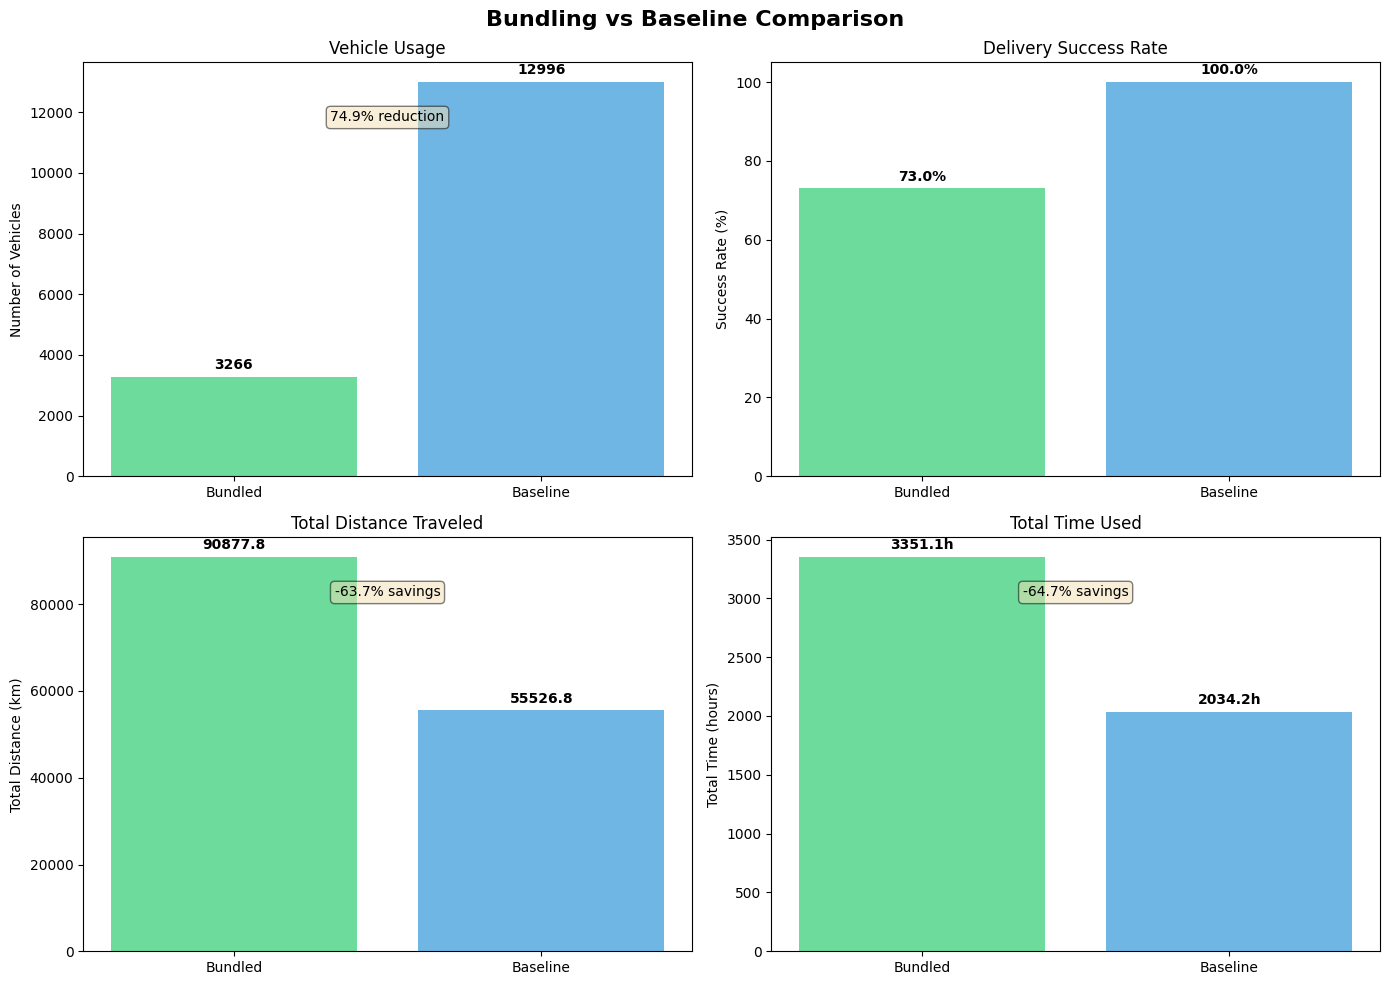

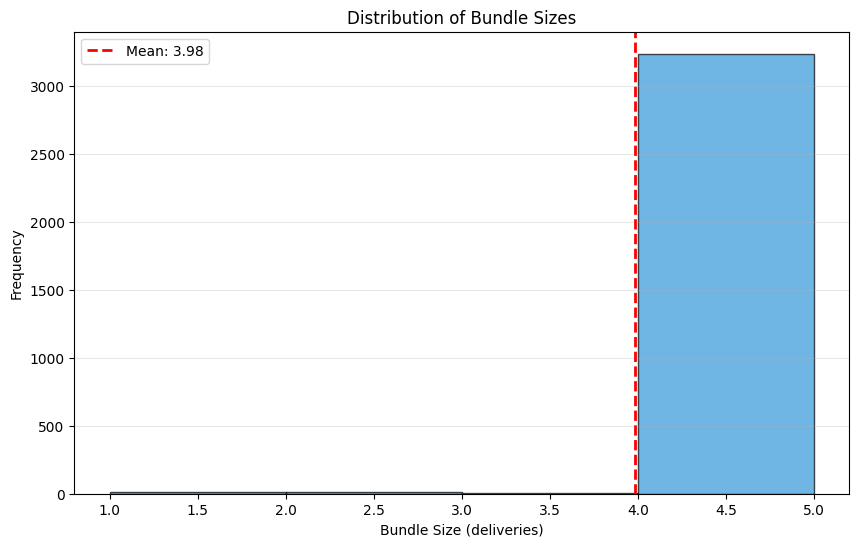

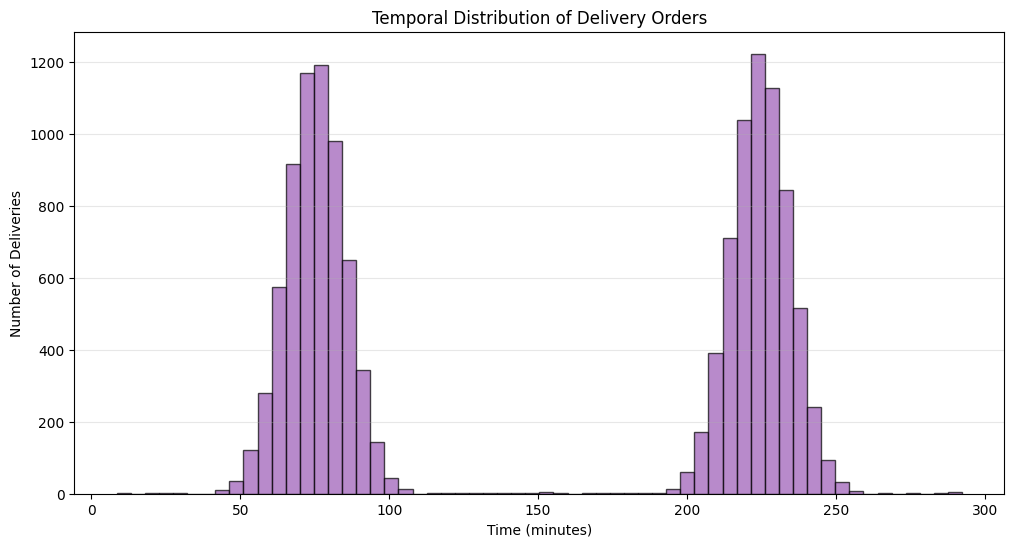


SIMULATION COMPLETE!
Vehicles saved: 9730
Distance saved: -35351.03 km


In [101]:
# ============================================================================
# USAGE EXAMPLE
# ============================================================================

# Example usage in your main script:

# Load your graph
umst_graph = nx.read_graphml(umst_path)

# Run simulation with fixed parameters
results = run_complete_simulation(
    umst_graph=umst_graph,
    num_deliveries=Config.NUM_DELIVERIES,
    max_bundle_size=Config.MAX_BUNDLE_SIZE,
    time_window=Config.TIME_WINDOW_SECONDS,  # 5 minutes (NOT 30000!)
    simulation_hours=Config.SIMULATION_HOURS,
    distance_based="closer",
    save_files=True
)

# Access results
print(f"Vehicles saved: {results['baseline_results']['num_vehicles'] - results['bundled_results']['num_vehicles']}")
print(f"Distance saved: {results['baseline_results']['total_distance_km'] - results['bundled_results']['total_distance_km']:.2f} km")

# For subsequent runs, you can load matrices:
# dist_matrix, time_matrix, node_to_idx, idx_to_node = load_matrices('matrices.pkl')
